In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
from astropy.io import fits

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df


In [3]:
with fits.open('astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

data = fitsrec_to_pandas(astronn_data)

data['MN_O'] = data['MN_H'] - data['O_H']
data['FE_O'] = data['FE_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']
data['MG_FE'] = data['MG_H'] - data['FE_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

# Create FE_H range arrays
feh_neg = np.linspace(data['FE_H'].min(), 0, 300)  # negative metallicity
feh_pos = np.linspace(0, data['FE_H'].max(), 300)  # positive metallicity

# Compute boundary line
mgfe_neg = 0.12 - 0.13 * feh_neg        # sloped part
mgfe_pos = np.full_like(feh_pos, 0.12)  # flat part at +0.12
feh_line = np.concatenate([feh_neg, feh_pos])
mgfe_line = np.concatenate([mgfe_neg, mgfe_pos])
mgh_line = mgfe_line + feh_line
femg_line = feh_line - mgh_line

In [4]:
def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/2307278332.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=[1,1])


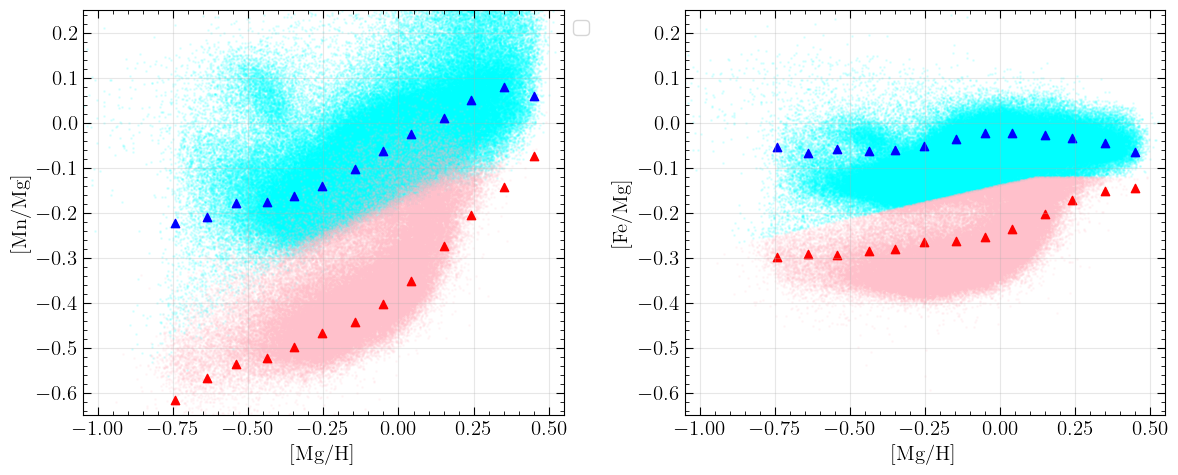

In [5]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink', s = 1)

plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')

plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/1197856837.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=[1,1])


(-1.05, 0.55)

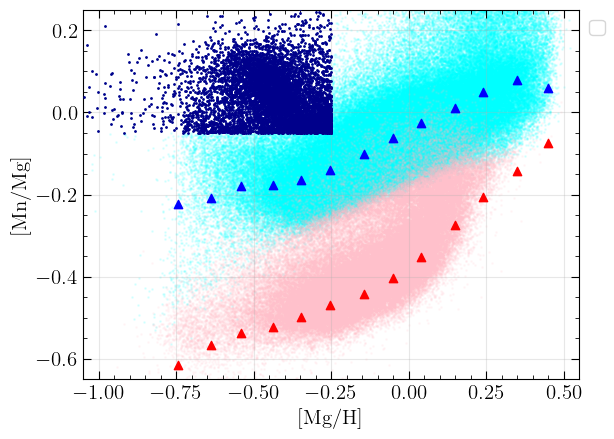

In [6]:
blob = data_low_alpha[(data_low_alpha['MG_H'] < -0.25) & (data_low_alpha['MN_MG'] > -0.05)]

plt.scatter(blob['MG_H'], blob['MN_MG'], s = 1, color = 'darkblue', zorder=5)

plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)


plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)

Text(0.5, 0, 'zmax')

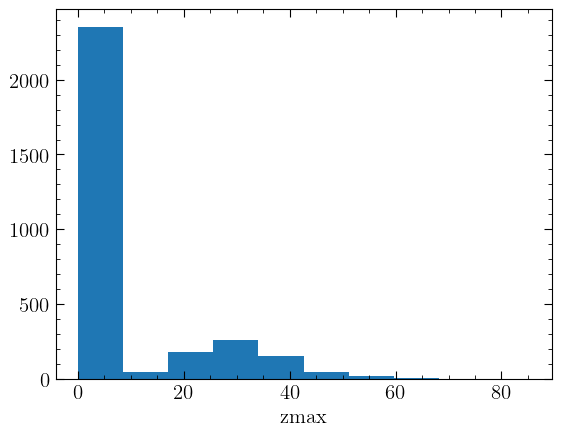

In [7]:
blob = blob[blob['zmax'] < 800]
blob_far = blob[blob['zmax'] > 10]
blob_near = blob[blob['zmax'] < 10]
plt.hist(blob['zmax'])
plt.xlabel('zmax')

Text(0.5, 0, 'galz')

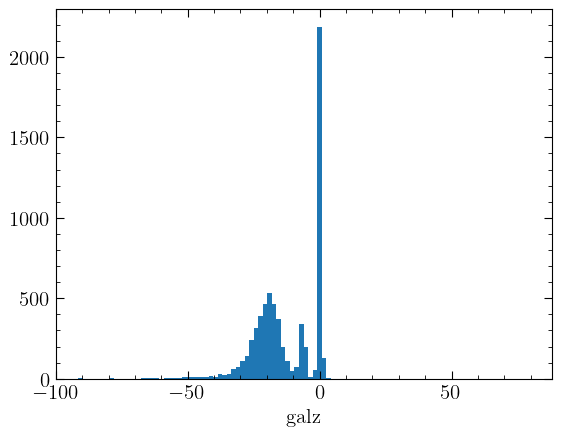

In [8]:
blob = data_low_alpha[(data_low_alpha['MG_H'] < -0.25) & (data_low_alpha['MN_MG'] > -0.05)]
blob = blob[blob['galz'] < 100]
blob = blob[blob['galz'] > -100]
blob_far = blob[blob['galz'] > 10]
blob_near = blob[blob['galz'] < 10]
plt.hist(blob['galz'], bins = 100)
plt.xlabel('galz')

(array([ 46.,  58.,  45.,  48.,  80., 384., 334., 777., 552., 149., 120.,
        162., 185., 161., 177., 211., 228., 298., 330., 298., 290., 297.,
        231., 200., 189., 142., 123., 122., 101.,  51.,  47.,  45.,  22.,
         21.,  26.,  18.,  22.,  20.,  10.,   9.,   5.,   5.,   5.,   8.,
          5.,   7.,   4.,   7.,   3.,   4.,   8.,   6.,   1.,   3.,   4.,
          5.,   4.,   4.,   1.,   0.,   1.,   1.,   3.,   0.,   2.,   1.,
          0.,   2.,   1.,   2.,   2.,   3.,   1.,   1.,   0.,   0.,   4.,
          1.,   0.,   2.,   0.,   0.,   0.,   1.,   1.,   1.,   2.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          2.]),
 array([  0.15205522,   1.60588648,   3.05971774,   4.513549  ,
          5.96738026,   7.42121151,   8.87504277,  10.32887403,
         11.78270529,  13.23653655,  14.69036781,  16.14419907,
         17.59803032,  19.05186158,  20.50569284,  21.9595241 ,
         23.41335536,  24.86718662,  26.32101787,  27.77484913

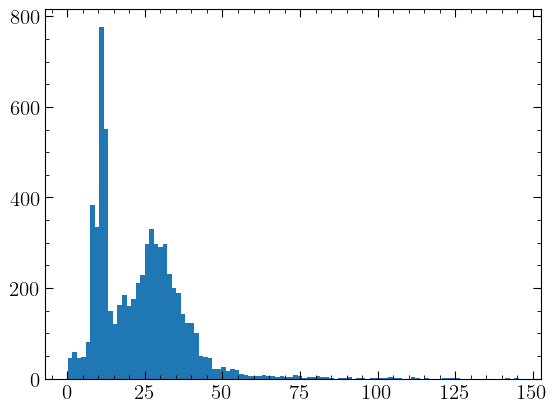

In [9]:
plt.hist(blob['galr'], bins = 100)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/1486046217.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=[1,1])


(-1.05, 0.55)

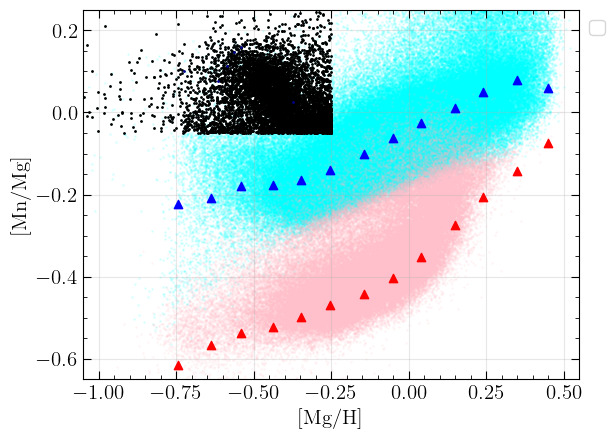

In [10]:
plt.scatter(blob_far['MG_H'], blob_far['MN_MG'], s = 1, color = 'darkblue', zorder=5)
plt.scatter(blob_near['MG_H'], blob_near['MN_MG'], s = 1, color = 'black', zorder=4)


plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)


plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)


plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/3613080393.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/3613080393.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/3613080393.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

(-1.05, 0.55)

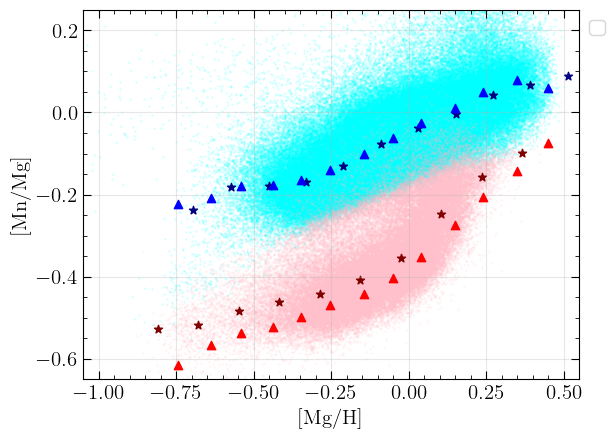

In [11]:
data_low_alpha = data_low_alpha[(data_low_alpha['galz'] < 2) & (data_low_alpha['galz'] > -2) &
                                (data_low_alpha['galr'] < 15) & (data_low_alpha['galr'] > 3)]

data_high_alpha = data_high_alpha[(data_high_alpha['galz'] < 2) & (data_high_alpha['galz'] > -2) &
                                (data_high_alpha['galr'] < 15) & (data_high_alpha['galr'] > 3)]

mnmg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
mnmg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
femg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)
femg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)

mnmg_high = mnmg_high[mnmg_high['count'] >= 100]
mnmg_low  = mnmg_low[mnmg_low['count']  >= 100]
femg_high = femg_high[femg_high['count'] >= 100]
femg_low  = femg_low[femg_low['count']  >= 100]


plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')

plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)

# CONST SFRS

Everything same as mock_stars_W2024_params, just changed stars abundances

In [12]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]
print("dt = ", dt)
tau_sfh_def = 6 #Gyrs
m_g_array_exp_def = 1 * np.exp(-t_array/tau_sfh_def)
m_g_array_const = np.ones(len(t_array))

tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 2.0]

gal1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars_2024[0], eta = etas_2024[0])
gal2 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars_2024[1], eta = etas_2024[1])
gal3 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars_2024[2], eta = etas_2024[2])

dt =  0.014013913913913914


In [13]:
mdot_star_consts = []
mstars_consts = []

for taustar in tau_stars_2024:
    mstars_consts.append(m_g_array_const/taustar * dt)


cdf_mstars_const_1 = np.cumsum(mstars_consts[0])/np.sum(mstars_consts[0])
cdf_mstars_const_2 = np.cumsum(mstars_consts[1])/np.sum(mstars_consts[1])
cdf_mstars_const_3 = np.cumsum(mstars_consts[2])/np.sum(mstars_consts[2])

In [14]:
# 2. Define how many samples you want
n_samples = 1000
# 3. Generate uniform random numbers
u = np.random.rand(n_samples)
# 4. Perform the inverse sampling to get indices
sampled_indices_1 = np.searchsorted(cdf_mstars_const_1, u)
sampled_indices_2 = np.searchsorted(cdf_mstars_const_2, u)
sampled_indices_3 = np.searchsorted(cdf_mstars_const_3, u)

error_on_met = 0.05
gal1_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])
gal2_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])
gal3_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O'])

gal1_df['O_H'] = np.random.normal(loc=gal1.O_H[sampled_indices_1], scale = error_on_met, size=n_samples)
gal1_df['Fe_O'] = np.random.normal(loc=gal1.Fe_O[sampled_indices_1], scale = error_on_met, size=n_samples)
gal1_df['Mn_O'] = np.random.normal(loc=gal1.Mn_O[sampled_indices_1], scale = error_on_met, size=n_samples)
gal1_df['time'] = np.random.normal(loc=gal1.t[sampled_indices_1], scale = error_on_met, size=n_samples)
gal1_df['age'] = t_array[-1] - gal1_df['time']

gal2_df['O_H'] = np.random.normal(loc=gal2.O_H[sampled_indices_2], scale = error_on_met, size=n_samples)
gal2_df['Fe_O'] = np.random.normal(loc=gal2.Fe_O[sampled_indices_2], scale = error_on_met, size=n_samples)
gal2_df['Mn_O'] = np.random.normal(loc=gal2.Mn_O[sampled_indices_2], scale = error_on_met, size=n_samples)
gal2_df['time'] = np.random.normal(loc=gal2.t[sampled_indices_2], scale = error_on_met, size=n_samples)
gal2_df['age'] = t_array[-1] - gal2_df['time']

gal3_df['O_H'] = np.random.normal(loc=gal3.O_H[sampled_indices_3], scale = error_on_met, size=n_samples)
gal3_df['Fe_O'] = np.random.normal(loc=gal3.Fe_O[sampled_indices_3], scale = error_on_met, size=n_samples)
gal3_df['Mn_O'] = np.random.normal(loc=gal3.Mn_O[sampled_indices_3], scale = error_on_met, size=n_samples)
gal3_df['time'] = np.random.normal(loc=gal3.t[sampled_indices_3], scale = error_on_met, size=n_samples)
gal3_df['age'] = t_array[-1] - gal3_df['time']

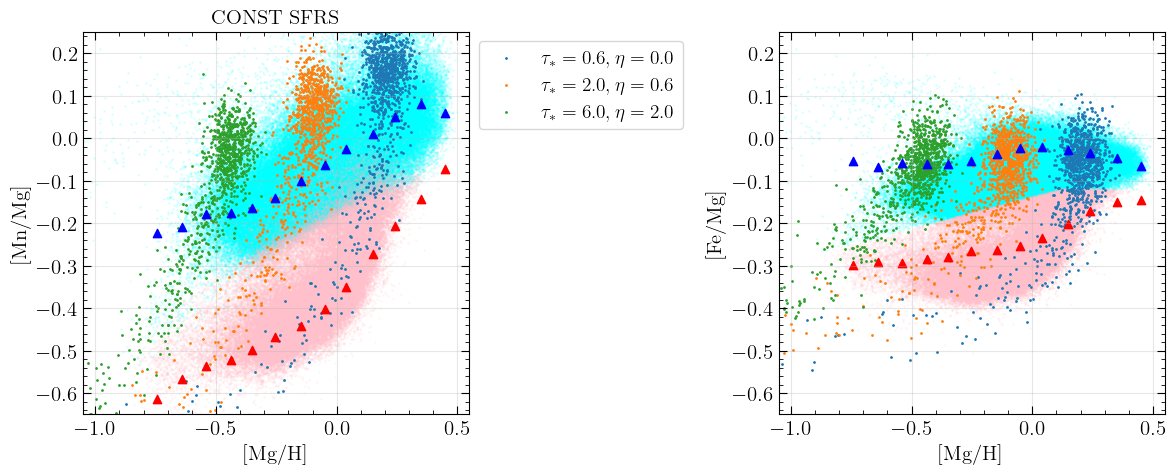

In [15]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Mn/Mg]'], marker='^', color = 'red', zorder=5)
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Mn/Mg]'], marker='^', color = 'blue', zorder=6)
plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')
plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal2.tau_star_arr[0]} , \eta = {gal2.eta_arr[0]} $')
plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s = 1, label = rf'$\tau_* = {gal3.tau_star_arr[0]} , \eta = {gal3.eta_arr[0]} $')
plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('CONST SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan', s = 1)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink', s = 1)
plt.scatter(gal1_df['O_H'], gal1_df['Fe_O'], s = 1)
plt.scatter(gal2_df['O_H'], gal2_df['Fe_O'], s = 1)
plt.scatter(gal3_df['O_H'], gal3_df['Fe_O'], s = 1)
plt.scatter(highalpha['[Mg/H]'], highalpha['[Fe/Mg]'], marker='^', color = 'red')
plt.scatter(lowalpha['[Mg/H]'], lowalpha['[Fe/Mg]'], marker='^', color = 'blue')
plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

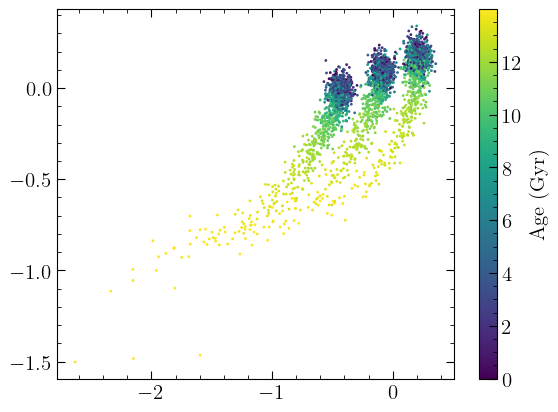

In [16]:
ages = t_array[-1] - t_array
vmin = ages.min()
vmax = ages.max()

sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s=1,
                  c=gal1_df['age'], cmap='viridis', vmin=vmin, vmax=vmax)

sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s=1,
                  c=gal2_df['age'], cmap='viridis', vmin=vmin, vmax=vmax)

sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s=1,
                  c=gal3_df['age'], cmap='viridis', vmin=vmin, vmax=vmax)

cbar = plt.colorbar(sc1)
cbar.set_label('Age (Gyr)')



/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/503402343.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=[1,1])


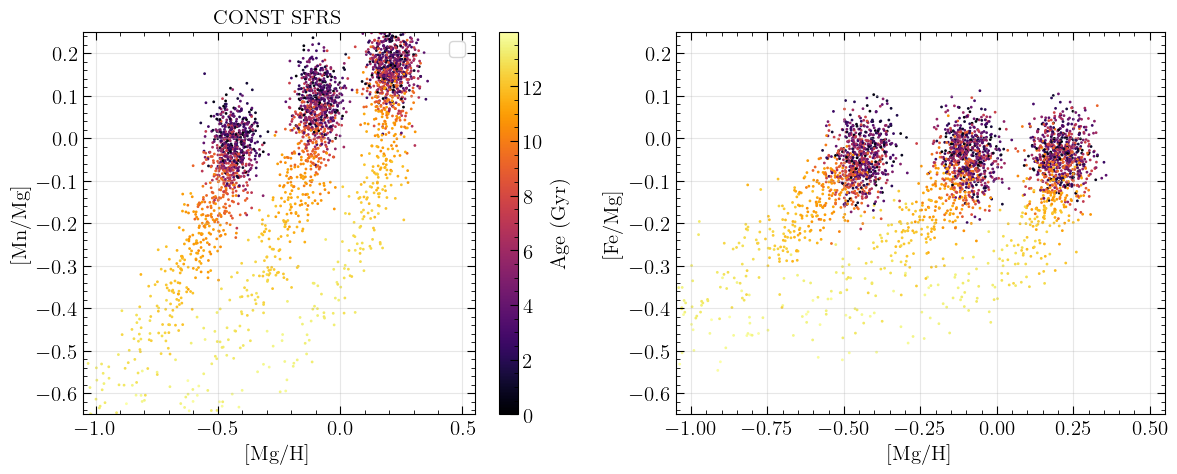

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
#plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.1, color = 'cyan', s = 1)
#plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.1, color = 'pink', s = 1)

ages = t_array[-1] - t_array
vmin = ages.min()
vmax = ages.max()

sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s=1, c=gal1_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s=1, c=gal2_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s=1, c=gal3_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
cbar = plt.colorbar(sc1)
cbar.set_label('Age (Gyr)')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('CONST SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
#plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.1, color = 'cyan', s = 1)
#plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.1, color = 'pink', s = 1)
sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Fe_O'], s=1, c=gal1_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Fe_O'], s=1, c=gal2_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Fe_O'], s=1, c=gal3_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
#cbar = plt.colorbar(sc1)
#cbar.set_label('Age (Gyr)')

plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

In [23]:
N = 10000

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
print(len(data_high_alpha))
print(len(data_low_alpha))

data_low_alpha = downsample(data_low_alpha, N)
data_high_alpha = downsample(data_high_alpha, N)

print(len(data_high_alpha))
print(len(data_low_alpha))

68308
191737
10000
10000


/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/3859530196.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=[1,1])


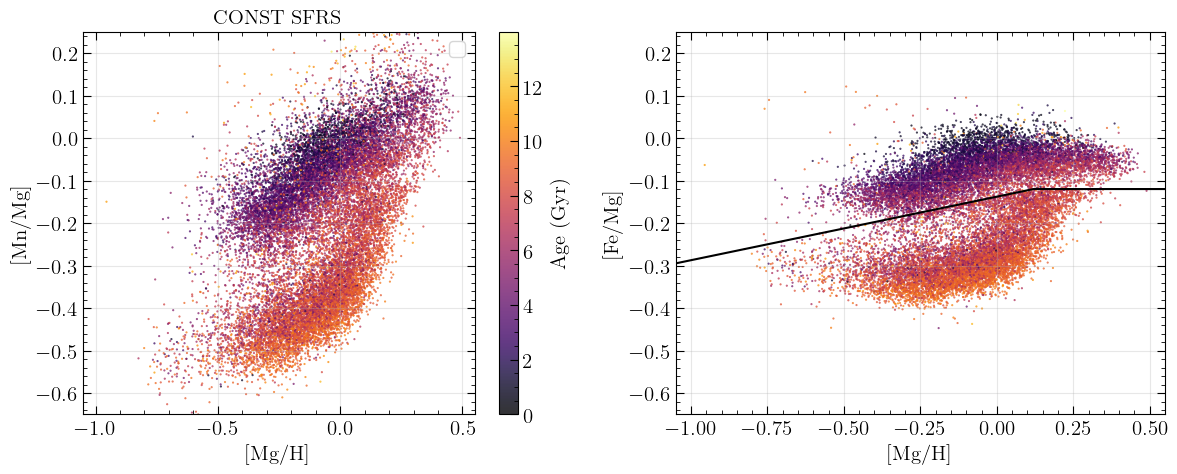

In [24]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sc_low = plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], c=data_low_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.8)
sc_high = plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], c=data_high_alpha['age'],
                      s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.8)


ages = t_array[-1] - t_array
vmin = ages.min()
vmax = ages.max()

cbar = plt.colorbar(sc_low)
cbar.set_label('Age (Gyr)')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('CONST SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
sc_low = plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], c=data_low_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.8)
sc_high = plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], c=data_high_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.8)
#cbar = plt.colorbar(sc1)
#cbar.set_label('Age (Gyr)')
plt.plot(mgh_line, femg_line, color = 'black')

plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/1731475618.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=[1,1])


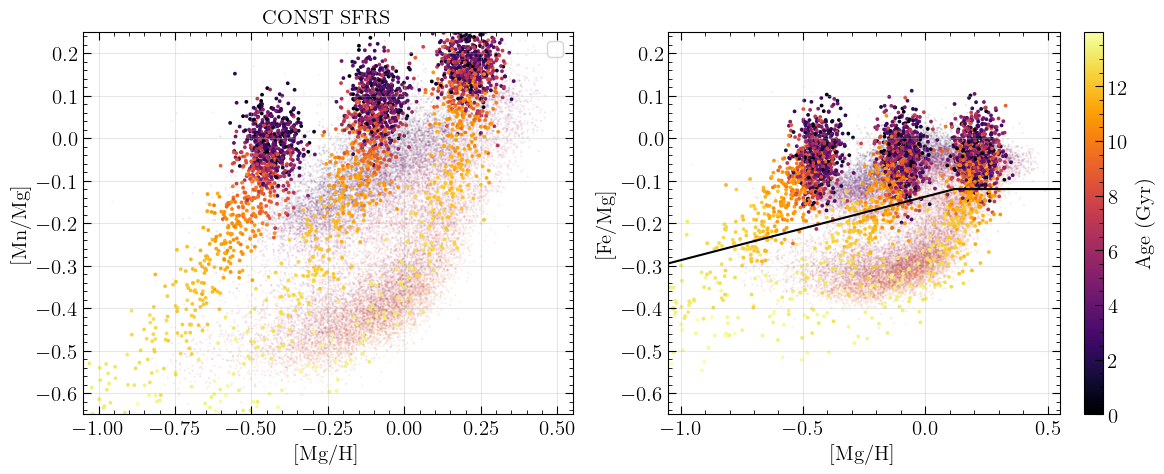

In [25]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sc_low = plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], c=data_low_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.1)
sc_high = plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], c=data_high_alpha['age'],
                      s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.1)

sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s=3, c=gal1_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s=3, c=gal2_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s=3, c=gal3_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)

ages = t_array[-1] - t_array
vmin = ages.min()
vmax = ages.max()

#sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s=1, c=gal1_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
#sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s=1, c=gal2_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
#sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s=1, c=gal3_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
#cbar = plt.colorbar(sc_low)
#cbar.set_label('Age (Gyr)')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('CONST SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
sc_low = plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], c=data_low_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.1)
sc_high = plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], c=data_high_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.1)

sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Fe_O'], s=3, c=gal1_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Fe_O'], s=3, c=gal2_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Fe_O'], s=3, c=gal3_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
cbar = plt.colorbar(sc1)
cbar.set_label('Age (Gyr)')
plt.plot(mgh_line, femg_line, color = 'black')

plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_13787/1982478081.py:24: UserWarning: Adding colorbar to a different Figure <Figure size 1200x500 with 4 Axes> than <Figure size 1200x1000 with 2 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(sc1)


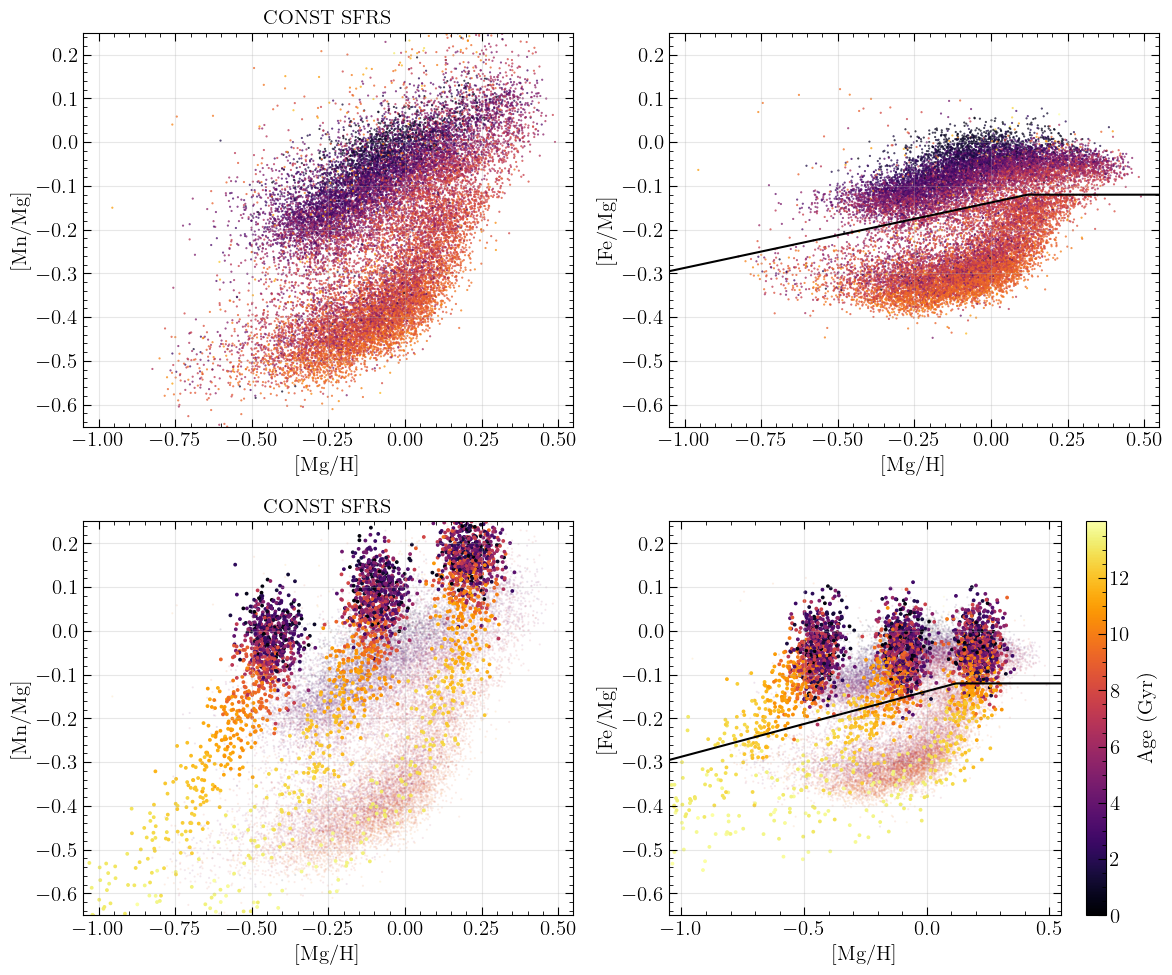

In [26]:
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
ages = t_array[-1] - t_array
vmin = ages.min()
vmax = ages.max()

sc_low = plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], c=data_low_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.8)
sc_high = plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], c=data_high_alpha['age'],
                      s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.8)

plt.grid('True', alpha = 0.3)
plt.ylim(-0.65,0.25)
plt.title('CONST SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)

plt.subplot(2,2,2)
sc_low = plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], c=data_low_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.8)
sc_high = plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], c=data_high_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.8)
cbar = plt.colorbar(sc1)
cbar.set_label('Age (Gyr)')
plt.plot(mgh_line, femg_line, color = 'black')

plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)


plt.subplot(2,2,3)
sc_low = plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], c=data_low_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.1)
sc_high = plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], c=data_high_alpha['age'],
                      s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.1)

sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s=3, c=gal1_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s=3, c=gal2_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s=3, c=gal3_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)

ages = t_array[-1] - t_array
vmin = ages.min()
vmax = ages.max()
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('CONST SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(2,2,4)
sc_low = plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], c=data_low_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.1)
sc_high = plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], c=data_high_alpha['age'],
                     s = 0.3, cmap='inferno', vmin=vmin, vmax=vmax, alpha = 0.1)

sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Fe_O'], s=3, c=gal1_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Fe_O'], s=3, c=gal2_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Fe_O'], s=3, c=gal3_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
cbar = plt.colorbar(sc1)
cbar.set_label('Age (Gyr)')
plt.plot(mgh_line, femg_line, color = 'black')

plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

In [21]:
low_alpha_low_z = data_low_alpha[data_low_alpha['zmax'] < 0.5]
low_alpha_mid_z = data_low_alpha[(data_low_alpha['zmax'] > 0.5) & (data_low_alpha['zmax'] < 1)]
low_alpha_high_z = data_low_alpha[data_low_alpha['zmax'] > 1]

high_alpha_low_z = data_high_alpha[data_high_alpha['zmax'] < 0.5]
high_alpha_mid_z = data_high_alpha[(data_high_alpha['zmax'] > 0.5) & (data_high_alpha['zmax'] < 1)]
high_alpha_high_z = data_high_alpha[data_high_alpha['zmax'] > 1]

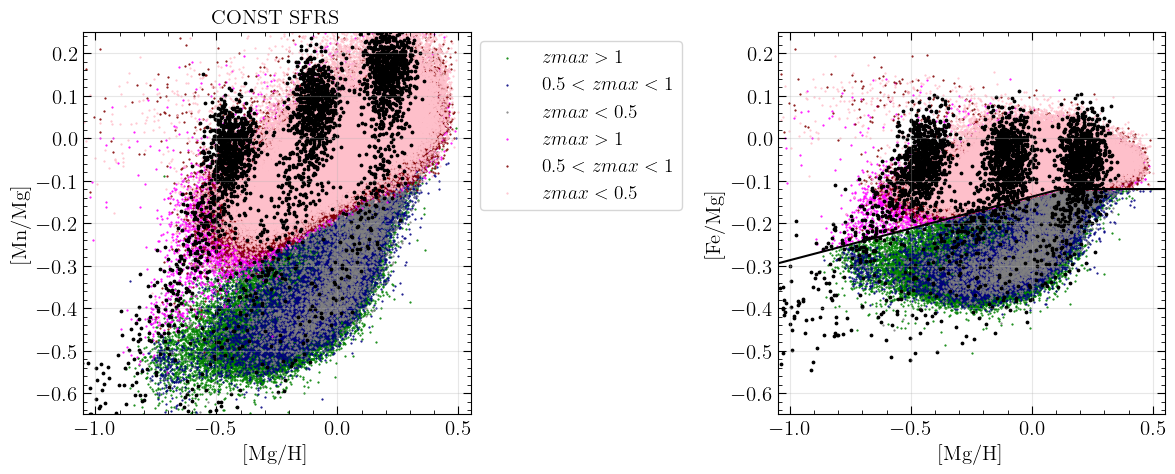

In [22]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(high_alpha_high_z['MG_H'], high_alpha_high_z['MN_MG'], color='green', s = 0.3, label = r'$zmax > 1$')
plt.scatter(high_alpha_mid_z['MG_H'], high_alpha_mid_z['MN_MG'], color='navy', s = 0.3, label = r'$0.5 < zmax < 1$')
plt.scatter(high_alpha_low_z['MG_H'], high_alpha_low_z['MN_MG'], color='gray', s = 0.3, label = r'$zmax < 0.5$')

plt.scatter(low_alpha_high_z['MG_H'], low_alpha_high_z['MN_MG'], color='magenta', s = 0.3, label = r'$zmax > 1$')
plt.scatter(low_alpha_mid_z['MG_H'], low_alpha_mid_z['MN_MG'], color='maroon', s = 0.3, label = r'$0.5 < zmax < 1$')
plt.scatter(low_alpha_low_z['MG_H'], low_alpha_low_z['MN_MG'], color='pink', s = 0.3, label = r'$zmax < 0.5$')

sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s=3, color = 'black')
sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s=3, color = 'black')
sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s=3, color = 'black')

ages = t_array[-1] - t_array
vmin = ages.min()
vmax = ages.max()

#sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Mn_O'], s=1, c=gal1_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
#sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Mn_O'], s=1, c=gal2_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
#sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Mn_O'], s=1, c=gal3_df['age'], cmap='inferno', vmin=vmin, vmax=vmax)
#cbar = plt.colorbar(sc_low)
#cbar.set_label('Age (Gyr)')

plt.legend(bbox_to_anchor=[1,1])
plt.grid('True', alpha = 0.3)

plt.ylim(-0.65,0.25)
plt.title('CONST SFRS')
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)

plt.scatter(high_alpha_high_z['MG_H'], high_alpha_high_z['FE_MG'], color='green', s = 0.3, label = r'$zmax > 1$')
plt.scatter(high_alpha_mid_z['MG_H'], high_alpha_mid_z['FE_MG'], color='navy', s = 0.3, label = r'$0.5 < zmax < 1$')
plt.scatter(high_alpha_low_z['MG_H'], high_alpha_low_z['FE_MG'], color='gray', s = 0.3, label = r'$zmax < 0.5$')

plt.scatter(low_alpha_high_z['MG_H'], low_alpha_high_z['FE_MG'], color='magenta', s = 0.3, label = r'$zmax > 1$')
plt.scatter(low_alpha_mid_z['MG_H'], low_alpha_mid_z['FE_MG'], color='maroon', s = 0.3, label = r'$0.5 < zmax < 1$')
plt.scatter(low_alpha_low_z['MG_H'], low_alpha_low_z['FE_MG'], color='pink', s = 0.3, label = r'$zmax < 0.5$')

sc1 = plt.scatter(gal1_df['O_H'], gal1_df['Fe_O'], s=3, color = 'black')
sc2 = plt.scatter(gal2_df['O_H'], gal2_df['Fe_O'], s=3, color = 'black')
sc3 = plt.scatter(gal3_df['O_H'], gal3_df['Fe_O'], s=3, color = 'black')

plt.plot(mgh_line, femg_line, color = 'black')

plt.grid('True', alpha = 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()